In [1]:
!pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('dataset.csv')
df.head(2)


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,30-01-2021,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.7,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,05-10-2026,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.0,3,228.0,Card,Online,USA,Low,3.9


In [5]:
df_sorted = df.sort_values('discount_percent', ascending=True)


In [6]:
# Create 5% discount intervals
bins = range(0, int(df_sorted['discount_percent'].max()) + 5, 5)
discount_binned = pd.cut(df_sorted['discount_percent'], bins=bins)
y = discount_binned.value_counts().sort_index()
x_labels = [f"{int(interval.left)}-{int(interval.right)}%" for interval in y.index]
x = range(len(y))

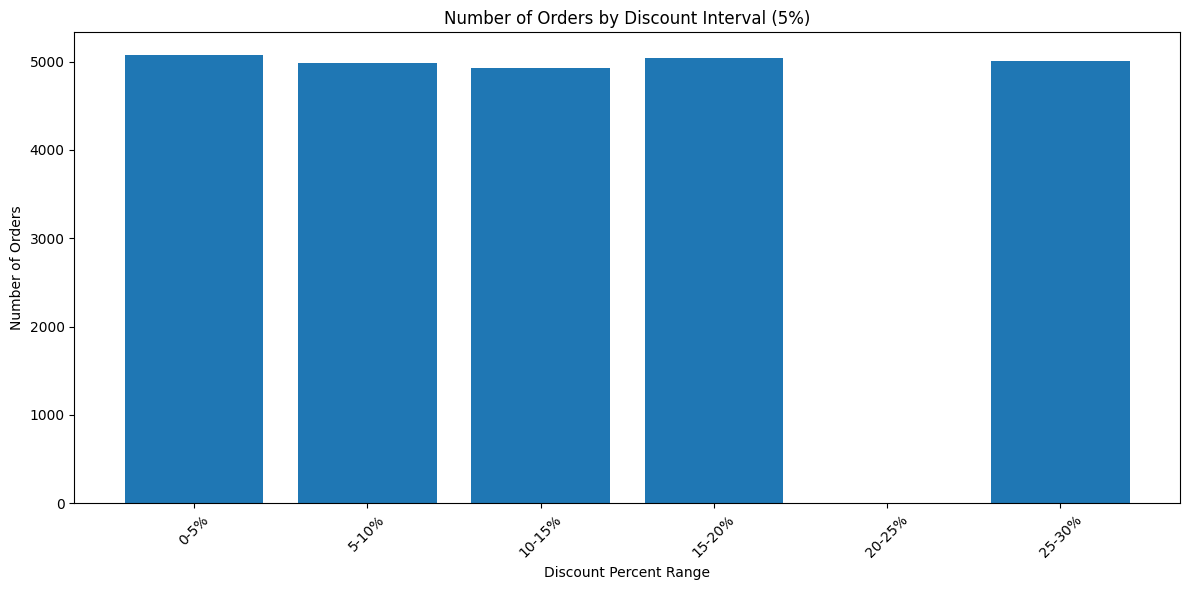

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(x, y)
plt.xticks(x, x_labels, rotation=45)
plt.xlabel('Discount Percent Range')
plt.ylabel('Number of Orders')
plt.title('Number of Orders by Discount Interval (5%)')
plt.tight_layout()
plt.show()

In [8]:
# Count shoes by brand and gender/type
shoes_by_brand_type = df.groupby(['brand', 'gender']).size().unstack(fill_value=0)
print("Number of Shoes Sold by Brand and Gender:")
print(shoes_by_brand_type)
print("\nTotal by Brand:")
print(shoes_by_brand_type.sum(axis=1))

Number of Shoes Sold by Brand and Gender:
gender        Men  Unisex  Women
brand                           
ASICS        1692    1660   1780
Adidas       1654    1577   1687
New Balance  1723    1609   1650
Nike         1662    1691   1665
Puma         1636    1611   1677
Reebok       1708    1720   1598

Total by Brand:
brand
ASICS          5132
Adidas         4918
New Balance    4982
Nike           5018
Puma           4924
Reebok         5026
dtype: int64


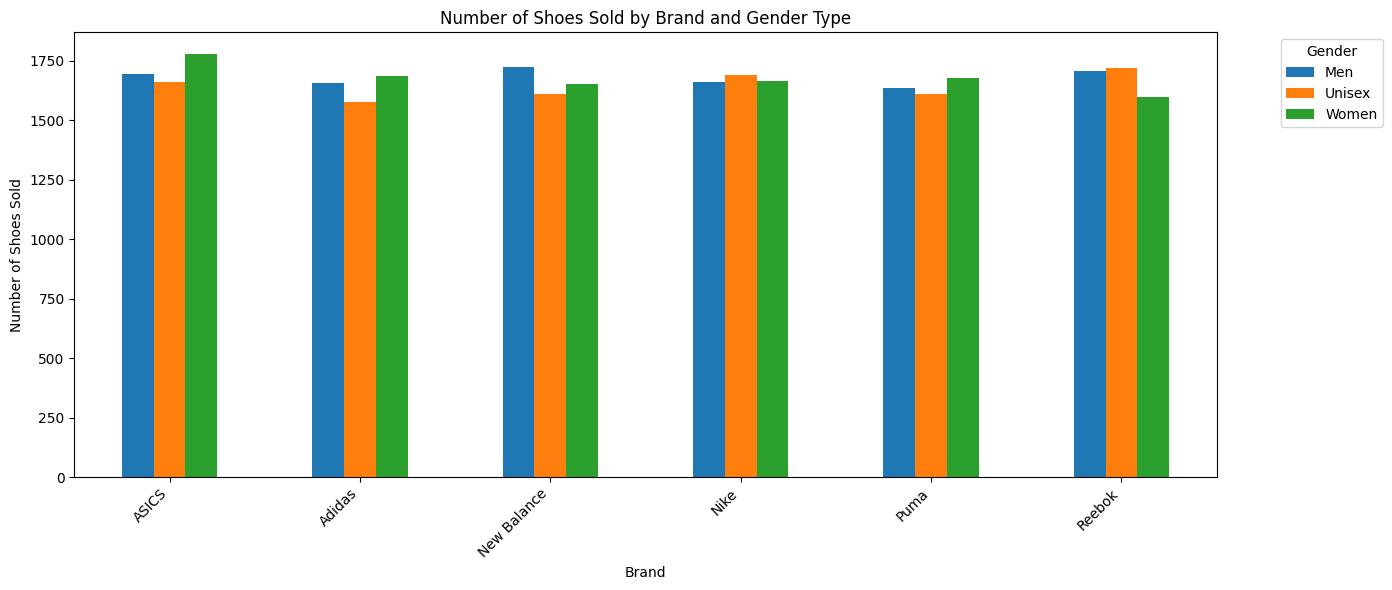

In [9]:
# Plot shoes by brand and gender type
fig, ax = plt.subplots(figsize=(14, 6))
shoes_by_brand_type.plot(kind='bar', ax=ax)
ax.set_xlabel('Brand')
ax.set_ylabel('Number of Shoes Sold')
ax.set_title('Number of Shoes Sold by Brand and Gender Type')
ax.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

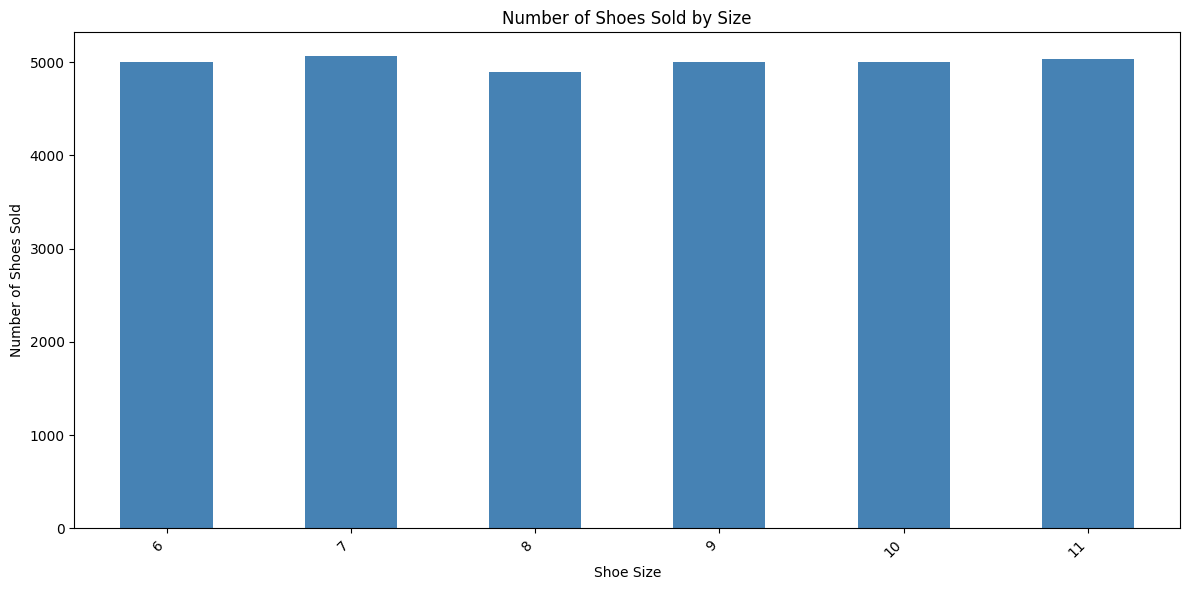


Shoes Sold by Size:
size
6     4999
7     5068
8     4901
9     5003
10    4998
11    5031
Name: count, dtype: int64


In [10]:
# Count shoes sold by size
shoes_by_size = df['size'].value_counts().sort_index()

# Plot shoes by size
fig, ax = plt.subplots(figsize=(12, 6))
shoes_by_size.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Shoe Size')
ax.set_ylabel('Number of Shoes Sold')
ax.set_title('Number of Shoes Sold by Size')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nShoes Sold by Size:")
print(shoes_by_size)

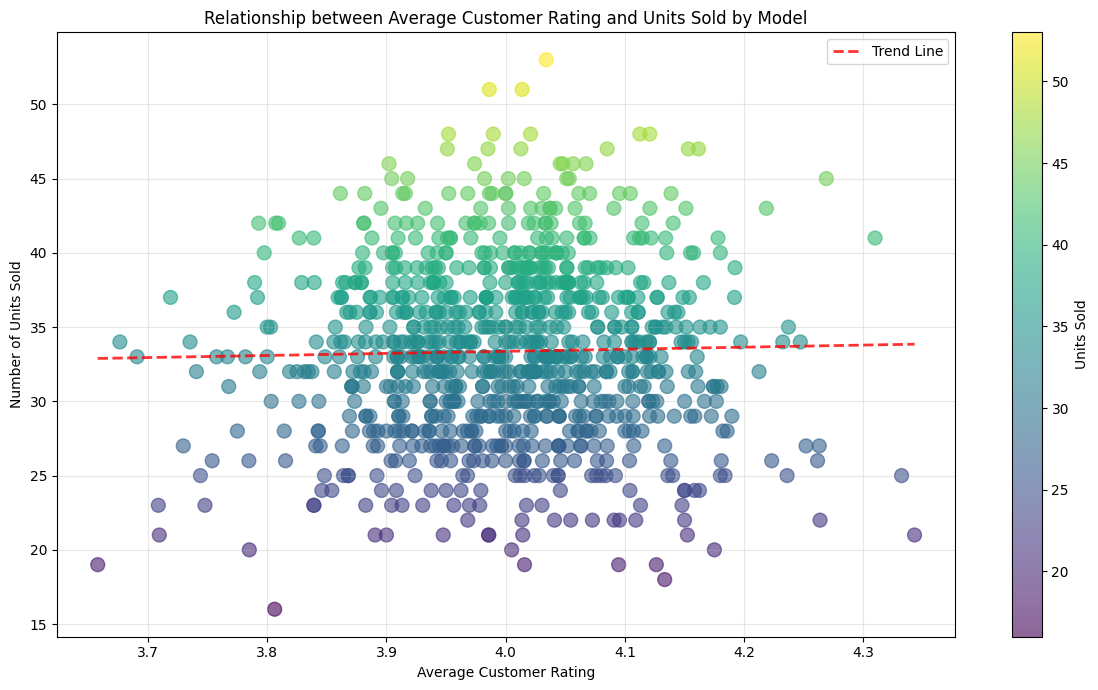


Model Analysis (Rating vs Units Sold):
            avg_rating  units_sold
model_name                        
Model-863     4.033962          53
Model-690     4.013725          51
Model-565     3.986275          51
Model-604     4.112500          48
Model-549     3.989583          48
...                ...         ...
Model-767     3.657895          19
Model-389     4.015789          19
Model-269     4.094737          19
Model-998     4.133333          18
Model-227     3.806250          16

[899 rows x 2 columns]


In [17]:
# Analyze relationship between average rating and units sold per model
model_analysis = df.groupby('model_name').agg({
    'customer_rating': 'mean',
    'order_id': 'count'
}).rename(columns={'customer_rating': 'avg_rating', 'order_id': 'units_sold'})

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(model_analysis['avg_rating'], model_analysis['units_sold'], 
                     s=100, alpha=0.6, c=model_analysis['units_sold'], cmap='viridis')
ax.set_xlabel('Average Customer Rating')
ax.set_ylabel('Number of Units Sold')
ax.set_title('Relationship between Average Customer Rating and Units Sold by Model')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Units Sold')

# Add trend line
z = np.polyfit(model_analysis['avg_rating'], model_analysis['units_sold'], 1)
p = np.poly1d(z)
ax.plot(model_analysis['avg_rating'].sort_values(), p(model_analysis['avg_rating'].sort_values()), 
        "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax.legend()

plt.tight_layout()
plt.show()

print("\nModel Analysis (Rating vs Units Sold):")
print(model_analysis.sort_values('units_sold', ascending=False))

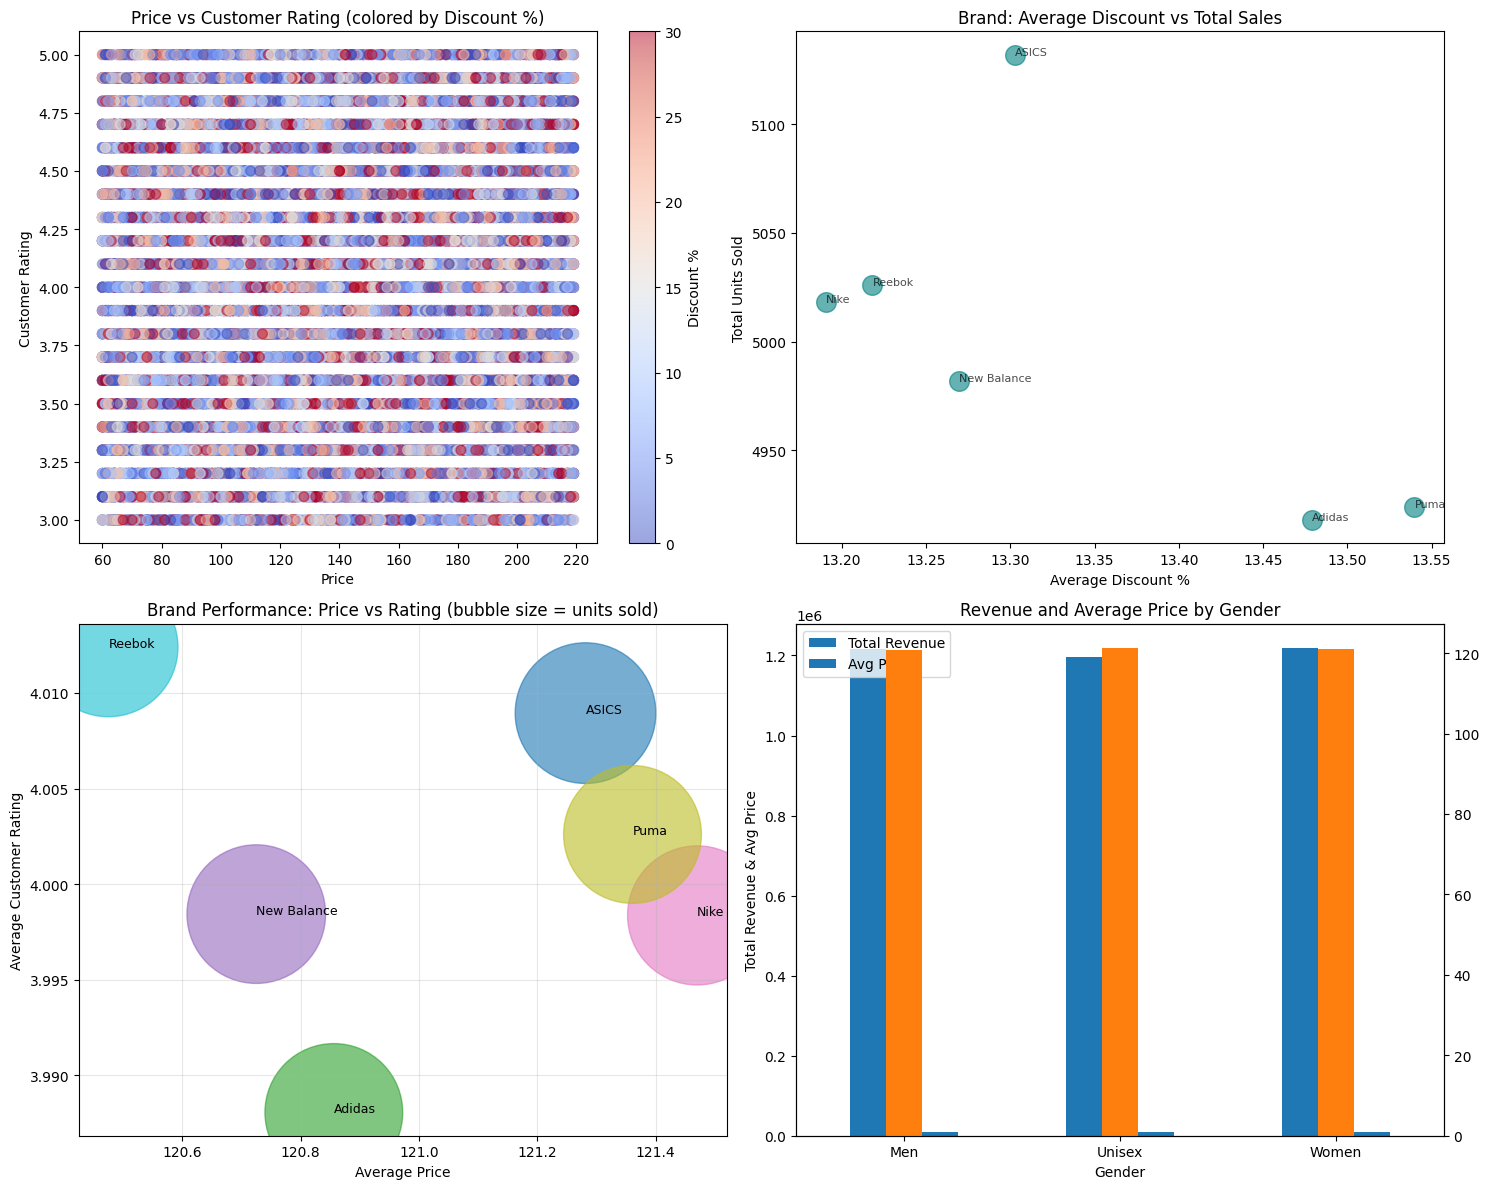


=== Unique Relationship Insights ===

1. Brand Performance Analysis:
             final_price_usd  customer_rating  order_id
brand                                                  
ASICS                 121.28             4.01      5132
Adidas                120.86             3.99      4918
New Balance           120.73             4.00      4982
Nike                  121.47             4.00      5018
Puma                  121.36             4.00      4924
Reebok                120.48             4.01      5026

2. Revenue by Gender:
        revenue_per_order  final_price_usd  order_id
gender                                              
Men            1216590.60           120.75     10075
Unisex         1196102.70           121.21      9868
Women          1218177.75           121.13     10057


In [22]:
# Unique Relationship 1: Price vs Customer Rating
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Price vs Rating scatter plot
ax1 = axes[0, 0]
scatter1 = ax1.scatter(df['base_price_usd'], df['customer_rating'], alpha=0.5, c=df['discount_percent'], cmap='coolwarm', s=50)
ax1.set_xlabel('Price')
ax1.set_ylabel('Customer Rating')
ax1.set_title('Price vs Customer Rating (colored by Discount %)')
plt.colorbar(scatter1, ax=ax1, label='Discount %')

# 2. Discount vs Units Sold by Brand
ax2 = axes[0, 1]
discount_sales = df.groupby('brand').agg({'discount_percent': 'mean', 'order_id': 'count'})
ax2.scatter(discount_sales['discount_percent'], discount_sales['order_id'], s=200, alpha=0.6, c='teal')
for idx, brand in enumerate(discount_sales.index):
    ax2.annotate(brand, (discount_sales['discount_percent'].iloc[idx], discount_sales['order_id'].iloc[idx]), 
                 fontsize=8, alpha=0.7)
ax2.set_xlabel('Average Discount %')
ax2.set_ylabel('Total Units Sold')
ax2.set_title('Brand: Average Discount vs Total Sales')

# 3. Brand Performance: Average Price vs Average Rating
ax3 = axes[1, 0]
brand_perf = df.groupby('brand').agg({'final_price_usd': 'mean', 'customer_rating': 'mean', 'order_id': 'count'})
scatter3 = ax3.scatter(brand_perf['final_price_usd'], brand_perf['customer_rating'], s=brand_perf['order_id']*2, 
                       alpha=0.6, c=range(len(brand_perf)), cmap='tab10')
for idx, brand in enumerate(brand_perf.index):
    ax3.annotate(brand, (brand_perf['final_price_usd'].iloc[idx], brand_perf['customer_rating'].iloc[idx]), fontsize=9)
ax3.set_xlabel('Average Price')
ax3.set_ylabel('Average Customer Rating')
ax3.set_title('Brand Performance: Price vs Rating (bubble size = units sold)')
ax3.grid(True, alpha=0.3)

# 4. Revenue Analysis: Price × Quantity by Gender
ax4 = axes[1, 1]
df['revenue_per_order'] = df['final_price_usd']
revenue_by_gender = df.groupby('gender').agg({'revenue_per_order': 'sum', 'final_price_usd': 'mean', 'order_id': 'count'})
revenue_by_gender.plot(secondary_y=['final_price_usd'], kind='bar', ax=ax4, color=['#1f77b4', '#ff7f0e'])
ax4.set_xlabel('Gender')
ax4.set_ylabel('Total Revenue & Avg Price')
ax4.set_title('Revenue and Average Price by Gender')
ax4.legend(['Total Revenue', 'Avg Price'], loc='upper left')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n=== Unique Relationship Insights ===\n")
print("1. Brand Performance Analysis:")
print(brand_perf.round(2))
print("\n2. Revenue by Gender:")
print(revenue_by_gender.round(2))

C:\Users\Ramachandran\AppData\Local\Temp\ipykernel_4184\2720793318.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  line = ax2_twin.plot(range(len(discount_rating)), discount_rating['customer_rating'], 'ro-', linewidth=2,


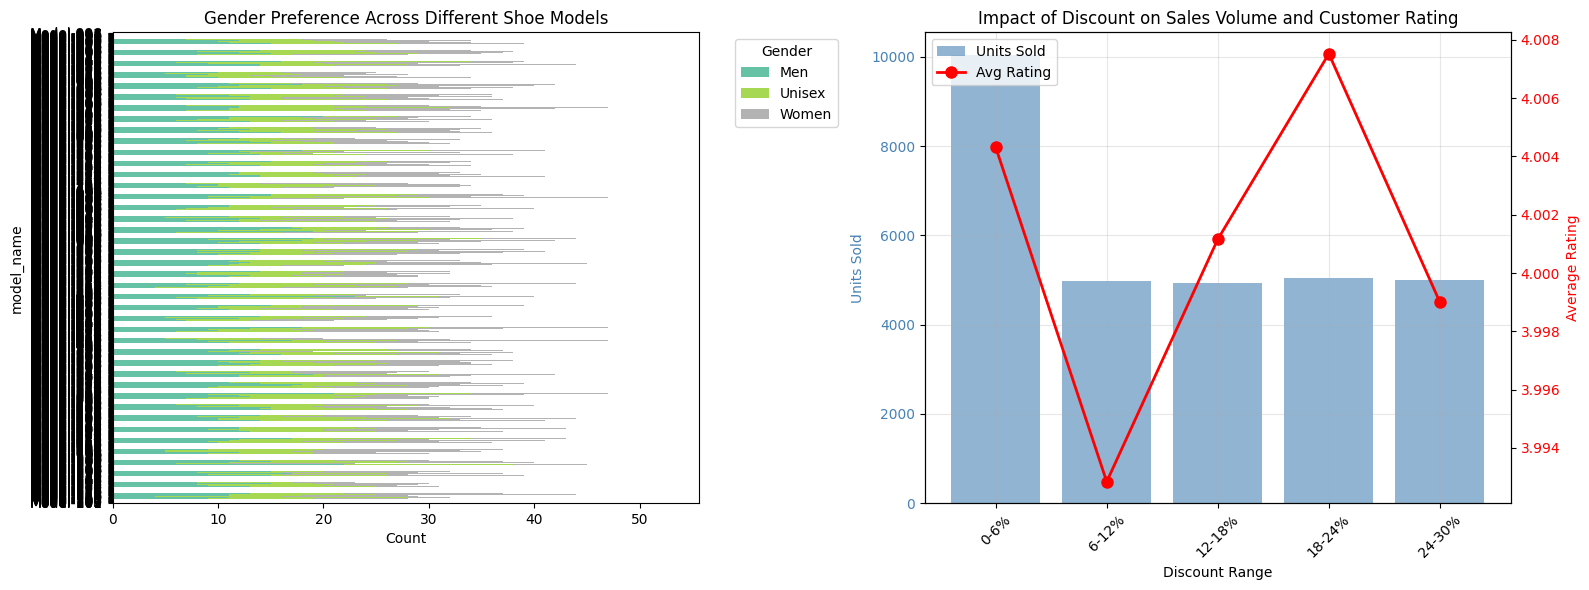


=== Additional Insights ===

Model Preference by Gender:
gender      Men  Unisex  Women
model_name                    
Model-100     7      13     20
Model-101     9       9     10
Model-102    10      10      8
Model-103     9       9     17
Model-104    10      14      9
...         ...     ...    ...
Model-994    11      11     10
Model-995     9      12     16
Model-996    15      11     15
Model-997    14      17      6
Model-998     5       5      8

[899 rows x 3 columns]


Discount Impact Analysis:
                  customer_rating  order_id
discount_percent                           
(-0.03, 6.0]                 4.00     10048
(6.0, 12.0]                  3.99      4986
(12.0, 18.0]                 4.00      4926
(18.0, 24.0]                 4.01      5037
(24.0, 30.0]                 4.00      5003


In [23]:
# Unique Relationship 2: Size Distribution by Gender & Brand Preference
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gender distribution across model types
ax1 = axes[0]
model_gender = df.groupby(['model_name', 'gender']).size().unstack(fill_value=0)
model_gender.plot(kind='barh', stacked=True, ax=ax1, colormap='Set2')
ax1.set_xlabel('Count')
ax1.set_title('Gender Preference Across Different Shoe Models')
ax1.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Correlation between Discount and Rating
ax2 = axes[1]
discount_rating = df.groupby(pd.cut(df['discount_percent'], bins=5)).agg({'customer_rating': 'mean', 'order_id': 'count'})
discount_rating_index = [f"{int(x.left)}-{int(x.right)}%" for x in discount_rating.index]
ax2_twin = ax2.twinx()
bars = ax2.bar(range(len(discount_rating)), discount_rating['order_id'], alpha=0.6, label='Units Sold', color='steelblue')
line = ax2_twin.plot(range(len(discount_rating)), discount_rating['customer_rating'], 'ro-', linewidth=2, 
                     markersize=8, label='Avg Rating', color='red')
ax2.set_xticks(range(len(discount_rating)))
ax2.set_xticklabels(discount_rating_index, rotation=45)
ax2.set_xlabel('Discount Range')
ax2.set_ylabel('Units Sold', color='steelblue')
ax2_twin.set_ylabel('Average Rating', color='red')
ax2.set_title('Impact of Discount on Sales Volume and Customer Rating')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\n=== Additional Insights ===\n")
print("Model Preference by Gender:")
print(model_gender)
print("\n\nDiscount Impact Analysis:")
print(discount_rating.round(2))

In [ ]:
# Unique Relationship 3: Correlation Analysis and Size-Price Relationship
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Correlation heatmap
ax1 = axes[0, 0]
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
im = ax1.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax1.set_xticks(range(len(numeric_cols)))
ax1.set_yticks(range(len(numeric_cols)))
ax1.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax1.set_yticklabels(numeric_cols)
ax1.set_title('Correlation Matrix of Numeric Features')
plt.colorbar(im, ax=ax1)

# Add correlation values to heatmap
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = ax1.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

# 2. Size popularity by price range
ax2 = axes[0, 1]
price_bins = pd.cut(df['final_price_usd'], bins=5)
size_price = df.groupby([price_bins, 'size']).size().unstack(fill_value=0)
size_price.plot(kind='bar', ax=ax2, colormap='tab10')
ax2.set_xlabel('Price Range')
ax2.set_ylabel('Count')
ax2.set_title('Size Popularity Across Different Price Ranges')
ax2.legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Brand loyalty (repeat customers analysis)
ax3 = axes[1, 0]
brand_stats = df.groupby('brand').agg({
    'customer_rating': 'mean',
    'final_price_usd': 'mean',
    'discount_percent': 'mean',
    'order_id': 'count'
}).sort_values('order_id', ascending=False)
brand_stats['order_id'].plot(kind='barh', ax=ax3, color='coral')
ax3.set_xlabel('Total Orders')
ax3.set_title('Brand Popularity (Total Orders)')

# 4. Price Distribution by Gender with Rating overlay
ax4 = axes[1, 1]
for gender in df['gender'].unique():
    gender_data = df[df['gender'] == gender]
    ax4.scatter(gender_data['final_price_usd'], gender_data['customer_rating'], 
               label=gender, alpha=0.6, s=50)
ax4.set_xlabel('Price')
ax4.set_ylabel('Customer Rating')
ax4.set_title('Price and Rating Distribution by Gender')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Correlation Analysis ===")
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))
print("\n\nBrand Statistics (Sorted by Orders):")
print(brand_stats.round(2))

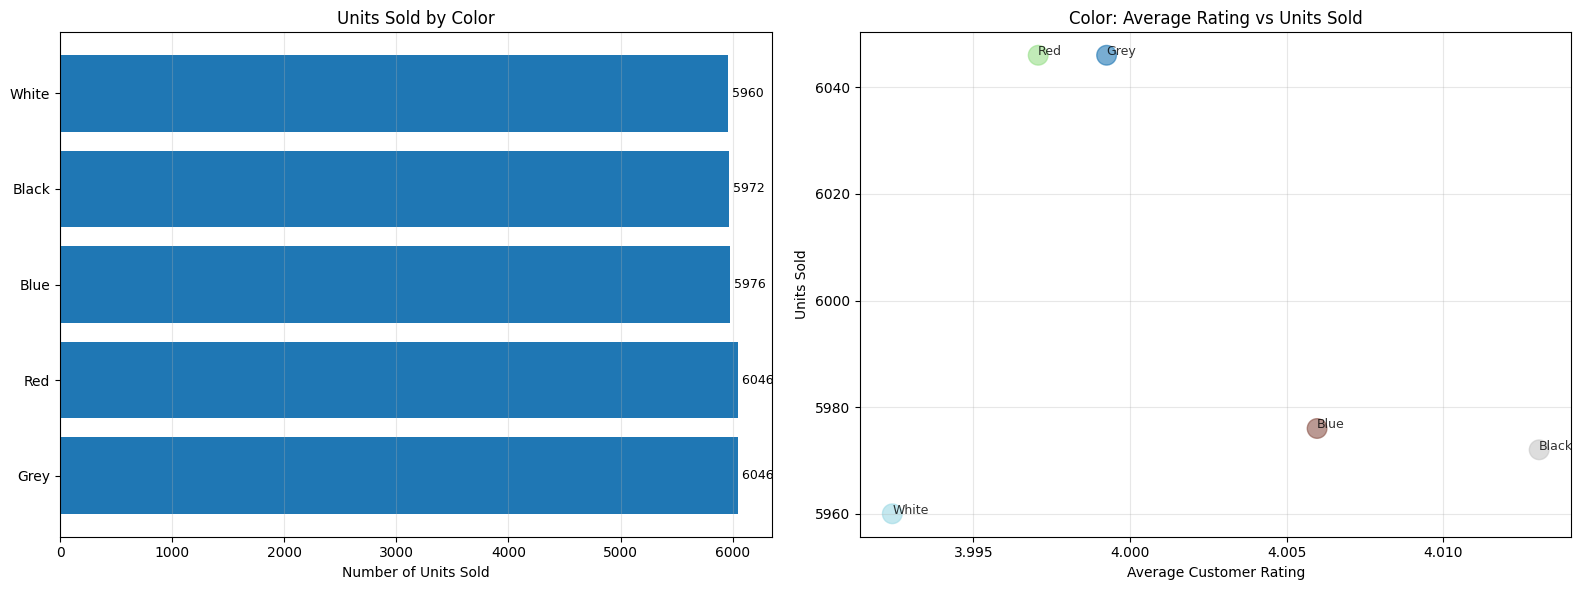


=== Color Analysis ===

Units Sold by Color:
color
Grey     6046
Red      6046
Blue     5976
Black    5972
White    5960
dtype: int64


Color Performance (Rating vs Units Sold):
       avg_rating  units_sold
color                        
Grey         4.00        6046
Red          4.00        6046
Blue         4.01        5976
Black        4.01        5972
White        3.99        5960


In [24]:
# Color vs Units Sold Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Color distribution - Units sold by color
ax1 = axes[0]
color_sales = df.groupby('color').size().sort_values(ascending=False)
bars = ax1.barh(range(len(color_sales)), color_sales.values)
ax1.set_yticks(range(len(color_sales)))
ax1.set_yticklabels(color_sales.index)
ax1.set_xlabel('Number of Units Sold')
ax1.set_title('Units Sold by Color')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, color_sales.values)):
    ax1.text(val, i, f' {int(val)}', va='center', fontsize=9)

# 2. Color vs Average Rating
ax2 = axes[1]
color_rating = df.groupby('color').agg({
    'customer_rating': 'mean',
    'order_id': 'count'
}).sort_values('order_id', ascending=False)
color_rating.columns = ['avg_rating', 'units_sold']

scatter = ax2.scatter(color_rating['avg_rating'], color_rating['units_sold'], 
                      s=200, alpha=0.6, c=range(len(color_rating)), cmap='tab20')
for idx, color_name in enumerate(color_rating.index):
    ax2.annotate(color_name, 
                (color_rating['avg_rating'].iloc[idx], color_rating['units_sold'].iloc[idx]),
                fontsize=9, alpha=0.8)
ax2.set_xlabel('Average Customer Rating')
ax2.set_ylabel('Units Sold')
ax2.set_title('Color: Average Rating vs Units Sold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Color Analysis ===\n")
print("Units Sold by Color:")
print(color_sales)
print("\n\nColor Performance (Rating vs Units Sold):")
print(color_rating.round(2))